In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import math
import random
from typing import Optional, Tuple
import warnings
warnings.filterwarnings('ignore')

In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


Using device: cuda
⚡ Fast BitNet b1.58 for Colab ⚡
Loaded 1115394 characters from file
Vocab size: 65
Dataset: 1115394 tokens, 1115330 sequences
Model parameters: 3,202,073

🚀 Starting fast training...
Epoch 1/5, Batch 0/17428, Loss: 4.469, Time: 0.3s
Epoch 1/5, Batch 20/17428, Loss: 3.491, Time: 1.3s
Epoch 1/5, Batch 40/17428, Loss: 3.246, Time: 2.2s
Epoch 1/5, Batch 60/17428, Loss: 2.980, Time: 3.2s
Epoch 1/5, Batch 80/17428, Loss: 2.861, Time: 4.2s
Epoch 1/5, Batch 100/17428, Loss: 2.770, Time: 5.1s
Epoch 1/5, Batch 120/17428, Loss: 2.684, Time: 6.1s
Epoch 1/5, Batch 140/17428, Loss: 2.672, Time: 7.1s
Epoch 1/5, Batch 160/17428, Loss: 2.587, Time: 8.0s
Epoch 1/5, Batch 180/17428, Loss: 2.598, Time: 9.0s
Epoch 1/5, Batch 200/17428, Loss: 2.575, Time: 9.9s
Epoch 1/5, Batch 220/17428, Loss: 2.552, Time: 10.9s
Epoch 1/5, Batch 240/17428, Loss: 2.551, Time: 11.8s
Epoch 1/5, Batch 260/17428, Loss: 2.513, Time: 12.8s
Epoch 1/5, Batch 280/17428, Loss: 2.509, Time: 13.8s
Epoch 1/5, Batch 300

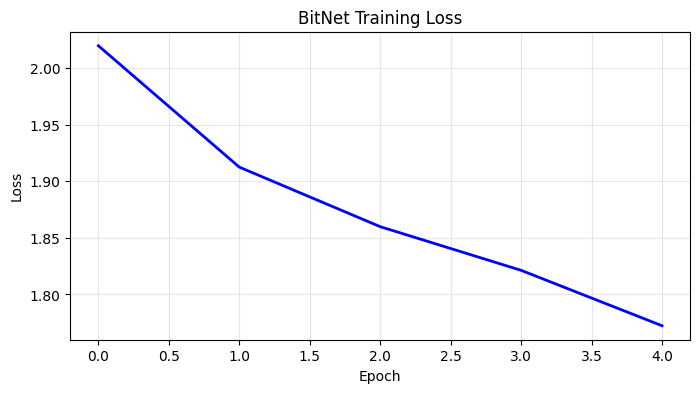


📝 Generating text samples...

'First Citizen:' ->
First Citizen:
The all not than est.

CHOMARFINIUROMEO:
Masters 
------------------------------

'MENENIUS:' ->
MENENIUS:
Morders in the now to they not him other my
to be
------------------------------

'Second Citizen:' ->
econd Citizen:
Mailhere that will all affice.

Servan thy come m
------------------------------

'All:' ->
All:
I me reme; one that the mane the prince aldory.


------------------------------

✅ Training completed successfully!
This model is now ready for Shakespeare-style text generation!


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader
import math
import time
from typing import Optional

# Set device and optimize for Colab
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Enable mixed precision for faster training
torch.backends.cudnn.benchmark = True

class BitLinear(nn.Module):
    """
    Efficient BitNet Linear Layer - simplified but faithful to original
    """
    def __init__(self, in_features, out_features): #in/out neurons
        super().__init__()
        self.in_features = in_features
        self.out_features = out_features

        # Weight parameter (will be quantized)
        self.weight = nn.Parameter(torch.randn(out_features, in_features) * 0.1) #0.1 to scale down the weights to -0.3 to +0.3

        # Learnable scaling factors
        self.weight_scale = nn.Parameter(torch.ones(1))

    def quantize_weights(self, w): #full precision weights to ternary values
        """Quantize weights to {-1, 0, +1} efficiently"""
        # Calculate scale (mean absolute value)
        scale = w.abs().mean().clamp(min=1e-5) #clamp to avoid division by zero that could cause instability.

        # Quantize with threshold
        w_norm = w / scale
        w_quant = torch.sign(w_norm) * (w_norm.abs() > 0.5).float() #step for ternary quantization, multiplying with w_norm removes smaller values

        return w_quant, scale

    def forward(self, x):
        # Quantize weights on-the-fly
        w_quant, w_scale = self.quantize_weights(self.weight)

        # Simple activation quantization (clamp to [-1, 1])
        x_quant = torch.clamp(x, -1, 1)

        # Compute output
        output = F.linear(x_quant, w_quant, None) #matrix multi

        # Apply learned scale
        return output * w_scale

class SimpleBitAttention(nn.Module):
    """Simplified BitNet Attention - much faster"""
    def __init__(self, dim, heads=4):
        super().__init__()
        self.heads = heads
        self.dim = dim
        self.head_dim = dim // heads
        self.scale = self.head_dim ** -0.5 #attention scaling factor

        # Single projection for QKV
        self.qkv = BitLinear(dim, dim * 3)
        self.proj = BitLinear(dim, dim) #After computing attention outputs, this layer merges all heads back into a single output tensor.
        #output shape: (batch, seq_len, dim * 3)

    def forward(self, x):
        B, L, D = x.shape #Batch size, seq length, embedding dimension

        # Get Q, K, V in one go
        qkv = self.qkv(x).reshape(B, L, 3, self.heads, self.head_dim)
        """
        self.qkv(x) computes a single linear transformation for Query, Key, and Value.
        Reshape & permute turns it into:
        q: shape (B, heads, L, head_dim)
        k: shape (B, heads, L, head_dim)
        v: shape (B, heads, L, head_dim)
        """
        q, k, v = qkv.permute(2, 0, 3, 1, 4)
        """
        shape of qkv: (B, L, 3, heads, head_dim), PERMUTES = REORDERING
        Before: (B, L, 3, heads, head_dim) --> After:  (3, B, heads, L, head_dim)

        """
        # Attention with causal mask
        attn = (q @ k.transpose(-2, -1)) * self.scale

        # Causal mask
        mask = torch.tril(torch.ones(L, L, device=x.device))
        attn = attn.masked_fill(mask == 0, float('-inf'))

        attn = F.softmax(attn, dim=-1)

        # Apply attention
        out = (attn @ v).transpose(1, 2).reshape(B, L, D)

        return self.proj(out)

class BitMLP(nn.Module):
    """Simplified BitNet MLP"""
    def __init__(self, dim):
        super().__init__()
        hidden_dim = dim * 2  # Smaller expansion ratio
        self.fc1 = BitLinear(dim, hidden_dim)
        self.fc2 = BitLinear(hidden_dim, dim)

    def forward(self, x):
        return self.fc2(F.gelu(self.fc1(x))) #GELU activation

class BitBlock(nn.Module):
    """Single BitNet Block - optimized"""
    def __init__(self, dim, heads=4):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)  # Faster than RMSNorm
        self.attn = SimpleBitAttention(dim, heads)
        self.norm2 = nn.LayerNorm(dim)
        self.mlp = BitMLP(dim)

    def forward(self, x):
        # Pre-norm architecture (more stable)
        x = x + self.attn(self.norm1(x))
        x = x + self.mlp(self.norm2(x))
        return x

class EfficientBitNet(nn.Module):
    """Lightweight BitNet Language Model"""
    def __init__(self, vocab_size, dim=128, depth=3, heads=4, max_len=128):
        super().__init__()
        self.dim = dim
        self.max_len = max_len

        # Embeddings
        self.token_emb = nn.Embedding(vocab_size, dim)
        self.pos_emb = nn.Embedding(max_len, dim)

        # Transformer blocks
        self.blocks = nn.ModuleList([BitBlock(dim, heads) for _ in range(depth)])

        # Output
        self.norm = nn.LayerNorm(dim)
        self.head = BitLinear(dim, vocab_size)

        # Initialize
        self.apply(self._init_weights)

    def _init_weights(self, module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=0.02)
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)

    def forward(self, x, targets=None):
        B, L = x.shape

        # Embeddings
        pos = torch.arange(L, device=x.device)
        x = self.token_emb(x) + self.pos_emb(pos) #Adds token and position embeddings

        # Transformer blocks
        for block in self.blocks:
            x = block(x)

        # Output
        x = self.norm(x)
        logits = self.head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(-1, logits.size(-1)), targets.view(-1))

        return logits, loss

class FastTokenizer:
    """Ultra-fast character tokenizer"""
    def __init__(self, text):
        chars = sorted(set(text))
        self.vocab_size = len(chars)
        self.char_to_idx = {ch: i for i, ch in enumerate(chars)}
        self.idx_to_char = {i: ch for i, ch in enumerate(chars)}
        print(f"Vocab size: {self.vocab_size}")

    def encode(self, text):
        return [self.char_to_idx[c] for c in text if c in self.char_to_idx]

    def decode(self, tokens):
        return ''.join([self.idx_to_char[t] for t in tokens])

class FastDataset(Dataset):
    """Memory-efficient dataset"""
    def __init__(self, tokens, seq_len=64):
        self.tokens = tokens
        self.seq_len = seq_len

    def __len__(self):
        return len(self.tokens) - self.seq_len

    def __getitem__(self, idx):
        x = torch.tensor(self.tokens[idx:idx + self.seq_len], dtype=torch.long)
        y = torch.tensor(self.tokens[idx + 1:idx + self.seq_len + 1], dtype=torch.long) #next token prediction
        """
        If tokens = [4, 5, 6, 7, 8] and seq_len = 3:
        x = [4, 5, 6]
        y = [5, 6, 7]
        """
        return x, y

def load_data():
    """Load Shakespeare data efficiently"""
    with open('/content/bitnet-dataset.txt', 'r', encoding='utf-8') as f:
        text = f.read()
    print(f"Loaded {len(text)} characters from file")
    return text  # <-- add this line


def train_fast(model, dataloader, epochs=5):
    """Fast training loop with progress tracking"""
    model.train()
    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=0.01)

    losses = []
    start_time = time.time()

    for epoch in range(epochs):
        epoch_loss = 0
        num_batches = len(dataloader)

        for i, (x, y) in enumerate(dataloader):
            x, y = x.to(device), y.to(device)

            optimizer.zero_grad()
            logits, loss = model(x, y)
            loss.backward()

            # Gradient clipping
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()
            epoch_loss += loss.item()

            # Progress update
            if i % 20 == 0:
                elapsed = time.time() - start_time
                print(f'Epoch {epoch+1}/{epochs}, Batch {i}/{num_batches}, '
                      f'Loss: {loss.item():.3f}, Time: {elapsed:.1f}s')

        avg_loss = epoch_loss / num_batches
        losses.append(avg_loss)
        print(f'Epoch {epoch+1} completed - Avg Loss: {avg_loss:.3f}')

    return losses

def generate_text(model, tokenizer, prompt="First Citizen:", max_len=100, temp=0.7):
    """Fast text generation"""
    model.eval()
    tokens = tokenizer.encode(prompt)

    with torch.no_grad():
        for _ in range(max_len):
            x = torch.tensor([tokens], device=device)
            logits, _ = model(x)

            # Sample next token
            probs = F.softmax(logits[0, -1] / temp, dim=-1)
            next_token = torch.multinomial(probs, 1).item()
            tokens.append(next_token)

            # Keep sequence length manageable
            if len(tokens) > model.max_len:
                tokens = tokens[-model.max_len:]

    return tokenizer.decode(tokens)

def main():
    print("⚡ Fast BitNet b1.58 for Colab ⚡")
    print("=" * 40)

    # Load data
    text = load_data()

    # Create tokenizer and dataset
    tokenizer = FastTokenizer(text)
    tokens = tokenizer.encode(text)

    # Small dataset for fast training
    dataset = FastDataset(tokens, seq_len=64)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=True, num_workers=0)

    print(f"Dataset: {len(tokens)} tokens, {len(dataset)} sequences")

    # Small but efficient model
    model = EfficientBitNet(
        vocab_size=tokenizer.vocab_size,
        dim=512,        # Small dimension
        depth=12,        # Few layers
        heads=16,        # Few heads
        max_len=256     # Short sequences
    ).to(device)

    # Count parameters
    total_params = sum(p.numel() for p in model.parameters())
    print(f"Model parameters: {total_params:,}")

    # Fast training
    print("\n🚀 Starting fast training...")
    losses = train_fast(model, dataloader, epochs=5)

    # Plot results
    plt.figure(figsize=(8, 4))
    plt.plot(losses, 'b-', linewidth=2)
    plt.title('BitNet Training Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, alpha=0.3)
    plt.show()

    # Generate samples
    print("\n📝 Generating text samples...")
    prompts = ["First Citizen:", "MENENIUS:", "Second Citizen:", "All:"]

    for prompt in prompts:
        print(f"\n'{prompt}' ->")
        generated = generate_text(model, tokenizer, prompt, max_len=50)
        print(generated)
        print("-" * 30)

    print("\n✅ Training completed successfully!")
    print("This model is now ready for Shakespeare-style text generation!")

if __name__ == "__main__":
    main()